In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os 
os.chdir('..')

In [24]:
import torch
from sklearn.model_selection import train_test_split
from fq_model.fq_classification import FQ_classification
import torch.nn.functional as F
from sklearn.metrics import accuracy_score
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

In [25]:
from uci_tests.cryotherapy.cryotheraphy import Cryotheraphy
from uci_tests.immunotherapy.immunotherapy import Immunotherapy
from uci_tests.haberman.haberman import Haberman
from uci_tests.iris.iris import Iris
from uci_tests.wine.wine import Wine
from uci_tests.heart.heart import Heart

X, y = Cryotheraphy().get_data()
# y = y - 1

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = "cpu"
print(device)
test_size=0.3
batch_size=63
random_state=90
num_epochs=2000
rules=3
lr=0.0005

cuda


In [30]:
train_accuracies = []
test_accuracies = []

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    
X_train = torch.Tensor(X_train).to(device)
X_test = torch.Tensor(X_test).to(device)
y_train = torch.Tensor(y_train).type(torch.LongTensor).to(device)
y_test = torch.Tensor(y_test).type(torch.LongTensor).to(device)

out_size = len(np.unique(y))
print('out_size', out_size)

# Initialize and move model to GPU
model = FQ_classification(in_features=X.shape[1], rules=rules, out_features=out_size).to(device)

# Initialize Adam optimizer
optimizer = optim.Adam(model.parameters(), lr=lr)

for epoch in range(num_epochs):
    model.train()
    for i in range(0, len(X_train), batch_size):
        optimizer.zero_grad()
        batch_X, batch_y = X_train[i:i+batch_size], y_train[i:i+batch_size]
        outputs = model(batch_X)
        loss = F.cross_entropy(outputs, batch_y)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        prediction = model(X_test).argmax(dim=1)
        accuracy = accuracy_score(y_test.cpu().numpy(), prediction.cpu().numpy())
        test_accuracies.append(accuracy)
        prediction = model(X_train).argmax(dim=1)
        accuracy = accuracy_score(y_train.cpu().numpy(), prediction.cpu().numpy())
        train_accuracies.append(accuracy)

# Calculate and print the average accuracy across all folds
avg_accuracy = max(test_accuracies)
print("max test accuracy:", avg_accuracy)
avg_accuracy = max(train_accuracies)
print("max train accuracy:", avg_accuracy)

out_size 2
max test accuracy: 0.9259259259259259
max train accuracy: 0.9841269841269841


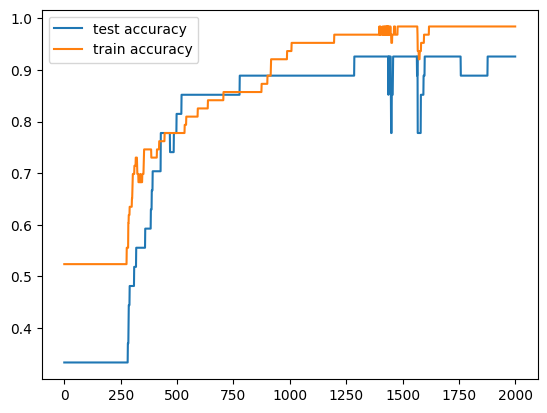

In [31]:
plt.plot(np.arange(len(test_accuracies)), test_accuracies)
plt.plot(np.arange(len(train_accuracies)), train_accuracies)
plt.legend(['test accuracy', 'train accuracy'])
plt.show()

IRIS = 94</br>
Cryotheraphy = 95</br>
Immunotherapy = 89</br>
Haberman = 74</br>
Wine = 89</br>
heart = 85</br>